# ML Rydberg Workflow

In [1]:
import qkernel
import numpy as np
import matplotlib.pyplot as plt
import snag
from sklearn.metrics import r2_score
from scipy.spatial.distance import pdist, squareform
from qkernel.utils import compute_excitation_count

## Generate Data

In [2]:
n_atoms = 4

def create_distortions(n):
    distances = np.random.uniform(1., 3., (n, n_atoms-1))
    return np.column_stack((np.zeros(n), np.cumsum(distances, 1)))

In [3]:
q_train = create_distortions(1000)
d_train = np.array([pdist(q[:, None]) for q in q_train])

q_test = create_distortions(100)
d_test = np.array([pdist(q[:, None]) for q in q_test])

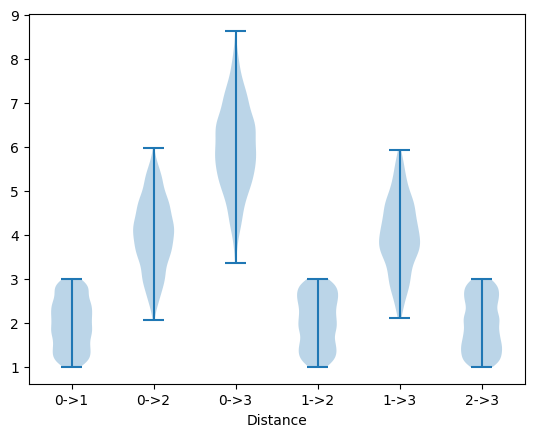

In [4]:
plt.violinplot(d_train, range(d_train.shape[1]))
plt.xlabel("Distance")
plt.xticks(range(d_train.shape[1]), [f"{i}->{j}" for i in range(n_atoms-1) for j in range(i+1, n_atoms)])
plt.show()

## Run Neutral Atom sims

In [5]:
def compute_probs(qs, scaling_fac=7):
    ham = qkernel.hamiltonian.QuTiPHamiltonian(qs * scaling_fac)
    sim = qkernel.simulator.QuTiPSimulator(ham.generate_hamiltonians_list())
    probs = np.array(sim.get_probabilities_list())[:, :, 0]
    return compute_excitation_count(probs)

In [6]:
p_train = compute_probs(q_train[:, :, None])
p_test = compute_probs(q_test[:, :, None])

kernel = qkernel.kernel.Kernel(p_train=p_train, distance_fn="exp_js")
g_train = kernel.compute_gram_train()
g_test = kernel.compute_gram_test(p_test=p_test)

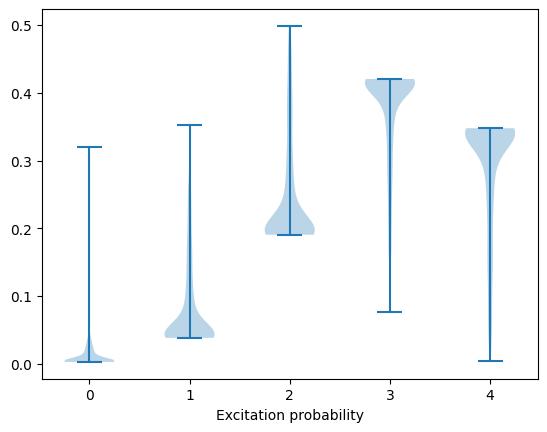

In [7]:
plt.violinplot(kernel.p_train)
plt.xticks(range(1, n_atoms+2), range(n_atoms+1))
plt.xlabel("Excitation probability")
plt.show()

## Solve Hubbard

In [8]:
calc = snag.Hubbard(n_up=1, n_dn=1, n_sites=n_atoms)
mol_calc = snag.HubbardMol(calc)

e_train = np.array([mol_calc.solve(d) for d in d_train])
e_test = np.array([mol_calc.solve(d) for d in d_test])

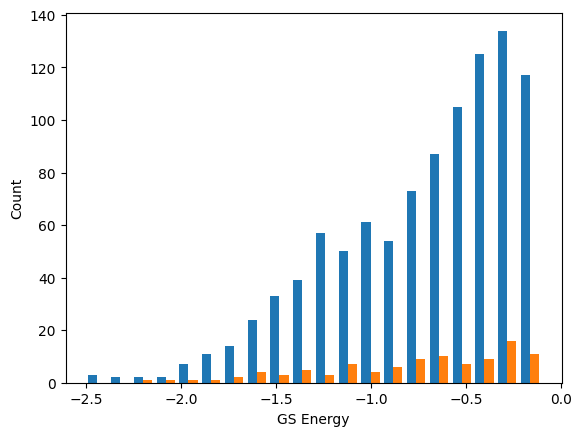

In [9]:
plt.hist([e_train, e_test], bins=20)
plt.xlabel("GS Energy")
plt.ylabel("Count")
plt.show()

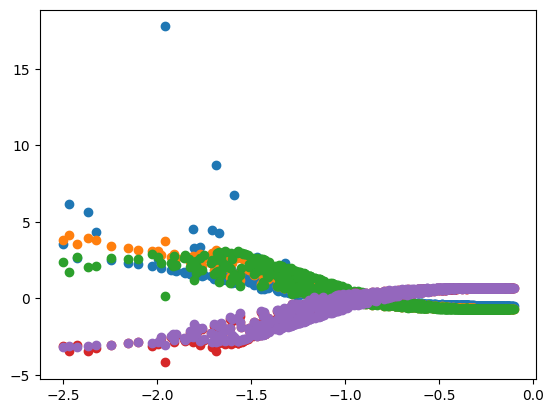

In [10]:
e_train_s = (e_train - np.mean(e_train)) / np.std(e_train)

for i in range(n_atoms+1):
    p_train_i_s = (p_train[:, i]-np.mean(p_train[:, i])) / np.std(p_train[:, i])
    plt.scatter(e_train, p_train_i_s)

## Fit Model

In [11]:
model = qkernel.model.KRR(alpha=1e-8)
model.train(g_train, e_train)
pred_train = model.predict(g_train)
pred_test = model.predict(g_test)

In [12]:
print("r2 train:", r2_score(e_train, pred_train))
print("r2 test:", r2_score(e_test, pred_test))

r2 train: 0.9963078996577809
r2 test: 0.996321391480414


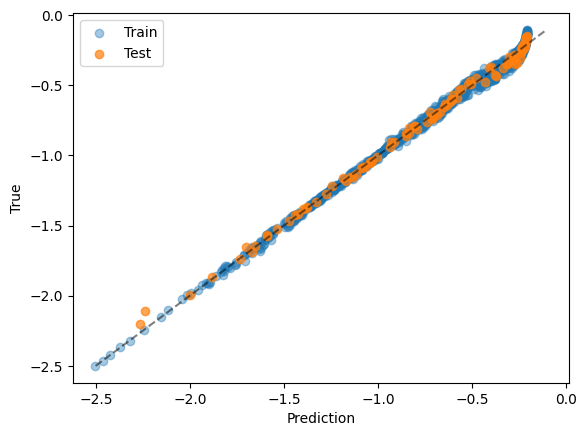

In [13]:
plt.scatter(pred_train, e_train, alpha=0.4, label="Train")
plt.scatter(pred_test, e_test, alpha=0.7, label="Test")
plt.xlabel("Prediction")
plt.ylabel("True")

bounds = [min(e_train), max(e_train)]
plt.legend()
plt.plot(bounds, bounds, ls="--", c="k", alpha=0.5)
plt.show()

## Generalization to separation

In [14]:
# 2*n chain bisection
n_chain = 4

ni_hoppings = squareform(
    snag.hubbard_mol.radial_hopping(pdist(np.arange(n_chain//2)[:, None]))
    )
non_int = snag.NonInteracting(ni_hoppings)
benchmark = 2*non_int.total_energy(1, 0)

calc = snag.Hubbard(n_up=1, n_dn=1, n_sites=n_chain)
calc_mol = snag.HubbardMol(calc)

distortions = np.linspace(0., 1.5, 20)
energies = []
mols = []

for d in distortions:
    x = np.arange(n_chain, dtype=float)
    x[n_chain//2:] = x[n_chain//2:] + d
    mols.append(x)
    pds = pdist(x[:, None])
    energies.append(calc_mol.solve(pds))

mols = np.array(mols)

In [15]:
p_cd = compute_probs(mols[:, :, None])
pred_cd = model.predict(kernel.compute_gram_test(p_cd))

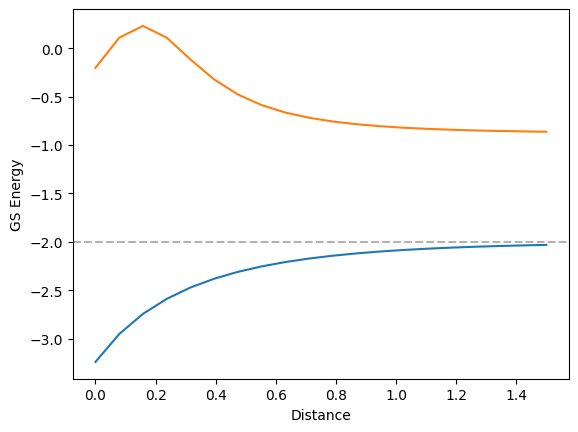

In [16]:
plt.plot(distortions, energies)
plt.plot(distortions, pred_cd)

plt.axhline(y=benchmark, ls='--', c='k', alpha=0.3)
plt.xlabel("Distance")
plt.ylabel("GS Energy")
plt.show()